In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/monthly.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'] >= '1971-01-01'].copy().reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Dataset shape: (662, 2)
Date range: 1971-01-01 00:00:00 to 2026-02-01 00:00:00


,Date,Price
0,1971-01-01,37.88
1,1971-02-01,38.74
2,1971-03-01,38.87
3,1971-04-01,39.01
4,1971-05-01,40.52


In [2]:
# Use last 24 months as test set
test_size = 24
train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

print(f"Train: {train['Date'].min().strftime('%Y-%m')} to {train['Date'].max().strftime('%Y-%m')} ({len(train)} months)")
print(f"Test:  {test['Date'].min().strftime('%Y-%m')} to {test['Date'].max().strftime('%Y-%m')} ({len(test)} months)")

Train: 1971-01 to 2024-02 (638 months)
Test:  2024-03 to 2026-02 (24 months)


In [5]:
# 1. Naive forecast — last known training value repeated
naive_pred = np.full(test_size, train['Price'].iloc[-1])

# 2. Historical average — mean of entire training set
hist_avg_pred = np.full(test_size, train['Price'].mean())

# 3. Window average — mean of last 12 months of training
window_pred = np.full(test_size, train['Price'].tail(12).mean())

# 4. Seasonal naive — same month from previous year
seasonal_naive_pred = []
fallback_value = train['Price'].iloc[-1]
for date in test['Date']:
    same_month_last_year = date - pd.DateOffset(years=1)
    match = train[train['Date'] == same_month_last_year]['Price']
    if len(match) > 0:
        seasonal_naive_pred.append(match.values[0])
    else:
        seasonal_naive_pred.append(fallback_value)
seasonal_naive_pred = np.array(seasonal_naive_pred)

print("Baseline predictions generated.")
print(f"Naive: {naive_pred[0]:.2f}")
print(f"Historical Avg: {hist_avg_pred[0]:.2f}")
print(f"Window Avg (12m): {window_pred[0]:.2f}")
print(f"Seasonal Naive (first value): {seasonal_naive_pred[0]:.2f}")

Baseline predictions generated.
Naive: 2023.24
Historical Avg: 664.31
Window Avg (12m): 1968.09
Seasonal Naive (first value): 1912.73


In [6]:
# Evaluate using Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error

mae_naive = mean_absolute_error(test['Price'], naive_pred)
mae_hist = mean_absolute_error(test['Price'], hist_avg_pred)
mae_window = mean_absolute_error(test['Price'], window_pred)
mae_seasonal = mean_absolute_error(test['Price'], seasonal_naive_pred)

results = pd.DataFrame({
    'Model': ['Naive', 'Historical Average', 'Window Average (12m)', 'Seasonal Naive'],
    'MAE': [mae_naive, mae_hist, mae_window, mae_seasonal]
}).sort_values('MAE')

print(results.to_string(index=False))

               Model         MAE
               Naive 1129.507500
      Seasonal Naive 1157.085000
Window Average (12m) 1184.662500
  Historical Average 2488.441337


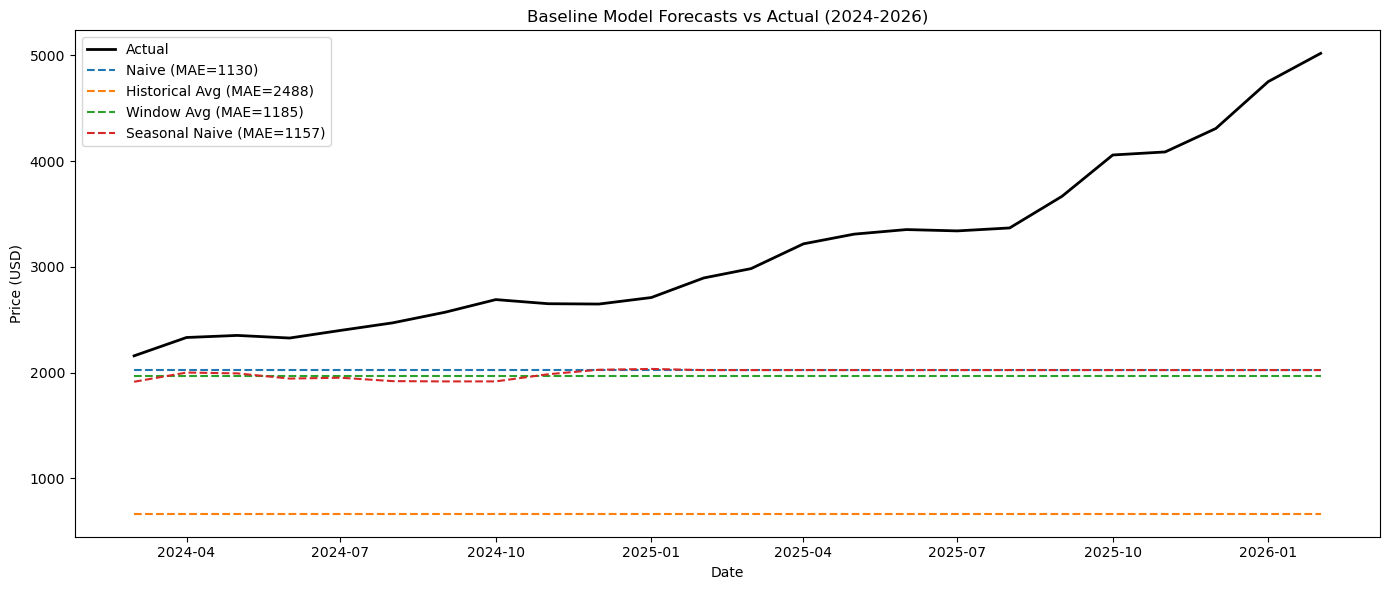

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(test['Date'], test['Price'], label='Actual', color='black', linewidth=2)
plt.plot(test['Date'], naive_pred, label=f'Naive (MAE={mae_naive:.0f})', linestyle='--')
plt.plot(test['Date'], hist_avg_pred, label=f'Historical Avg (MAE={mae_hist:.0f})', linestyle='--')
plt.plot(test['Date'], window_pred, label=f'Window Avg (MAE={mae_window:.0f})', linestyle='--')
plt.plot(test['Date'], seasonal_naive_pred, label=f'Seasonal Naive (MAE={mae_seasonal:.0f})', linestyle='--')
plt.title('Baseline Model Forecasts vs Actual (2024-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()